# GAN - ArtBench

## Imports

In [65]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [66]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

import random
'''
seed = random.randint(0, 500)
set_seed(seed)
print(f"Using seed: {seed}")'''

seed=3
set_seed(seed)

In [67]:
IMAGE_SIZE = 32
BATCH_SIZE = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 50

# Learning rate for optimizers
#lr = 0.0002
lr = 1e-4
# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [68]:
DEVIDE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVIDE)


Device: cuda


## Dataset

In [69]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [70]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [71]:
transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [72]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [73]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [74]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


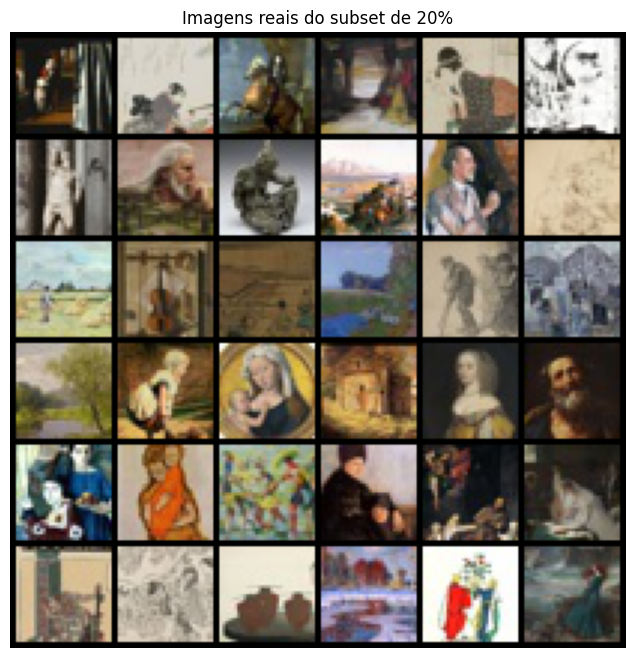

Exemplos de labels:
0: classe=baroque 
1: classe=ukiyo_e 
2: classe=baroque 
3: classe=surrealism 
4: classe=ukiyo_e 
5: classe=art_nouveau 
6: classe=renaissance 
7: classe=surrealism 
8: classe=surrealism 
9: classe=romanticism 
10: classe=impressionism 
11: classe=post_impressionism 


In [75]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## GAN

https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html#what-is-a-gan

### Weight Initialization

In [76]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


### Generator

In [77]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z (nz x 1 x 1), going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size: ``(ngf*4) x 4 x 4``
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size: ``(ngf*2) x 8 x 8``
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size: ``(ngf) x 16 x 16``
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size: ``(nc) x 32 x 32``
        )

    def forward(self, input):
        return self.main(input)


In [78]:
# Create the generator
netG = Generator(ngpu).to(DEVIDE)

# Handle multi-GPU if desired
if (DEVIDE.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


### Discriminator

In [79]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 32 x 32``
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: ``(ndf) x 16 x 16``
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: ``(ndf*2) x 8 x 8``
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size: ``(ndf*4) x 4 x 4``
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # state size: ``1 x 1 x 1``
        )

    def forward(self, input):
        return self.main(input)


In [80]:
# Create the Discriminator
netD = Discriminator(ngpu).to(DEVIDE)

# Handle multi-GPU if desired
if (DEVIDE.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)


In [81]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=DEVIDE)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))



print("Generator params:", sum(p.numel() for p in netG.parameters()))
print("Discriminator params:", sum(p.numel() for p in netD.parameters()))

Generator params: 1068928
Discriminator params: 663296


In [82]:
with torch.no_grad():
    z = torch.randn(8, nz, 1, 1, device=DEVIDE)
    fake = netG(z)
    out = netD(fake)

print("Fake batch shape:", fake.shape)
print("Discriminator output shape:", out.shape)

Fake batch shape: torch.Size([8, 3, 32, 32])
Discriminator output shape: torch.Size([8, 1, 1, 1])


In [83]:
import torchvision.utils as vutils

def train_gan(netG, netD, train_loader, criterion, optimizerG, optimizerD,
              nz, num_epochs, real_label, fake_label, fixed_noise, device):
    img_list = []
    G_losses = []
    D_losses = []
    iters = 0

    print("Starting Training Loop...")
    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader, 0):

            ############################
            # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
            ###########################
            netD.zero_grad()
            real_cpu = data[0].to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

            output = netD(real_cpu).view(-1)
            errD_real = criterion(output, label)
            errD_real.backward()
            D_x = output.mean().item()

            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            label.fill_(fake_label)

            output = netD(fake.detach()).view(-1)
            errD_fake = criterion(output, label)
            errD_fake.backward()
            D_G_z1 = output.mean().item()

            errD = errD_real + errD_fake
            optimizerD.step()

            ############################
            # (2) Update G network: maximize log(D(G(z)))
            ###########################
            netG.zero_grad()
            label.fill_(real_label)

            output = netD(fake).view(-1)
            errG = criterion(output, label)
            errG.backward()
            D_G_z2 = output.mean().item()
            optimizerG.step()

            if i % 50 == 0:
                print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                      % (epoch, num_epochs, i, len(train_loader),
                         errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

            G_losses.append(errG.item())
            D_losses.append(errD.item())

            if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(train_loader) - 1)):
                with torch.no_grad():
                    fake_fixed = netG(fixed_noise).detach().cpu()
                img_list.append(vutils.make_grid(fake_fixed, padding=2, normalize=True))

            iters += 1

    return G_losses, D_losses, img_list


# Run training with current models
G_losses, D_losses, img_list = train_gan(
    netG, netD, train_loader, criterion, optimizerG, optimizerD,
    nz, num_epochs, real_label, fake_label, fixed_noise, DEVIDE
)


Starting Training Loop...
[0/50][0/157]	Loss_D: 1.5331	Loss_G: 1.2106	D(x): 0.6623	D(G(z)): 0.6219 / 0.3360
[0/50][50/157]	Loss_D: 0.2533	Loss_G: 3.5352	D(x): 0.8896	D(G(z)): 0.1108 / 0.0348
[0/50][100/157]	Loss_D: 0.1198	Loss_G: 4.6168	D(x): 0.9357	D(G(z)): 0.0487 / 0.0121
[0/50][150/157]	Loss_D: 0.0569	Loss_G: 5.3293	D(x): 0.9810	D(G(z)): 0.0365 / 0.0060
[1/50][0/157]	Loss_D: 0.1098	Loss_G: 5.5515	D(x): 0.9799	D(G(z)): 0.0841 / 0.0049
[1/50][50/157]	Loss_D: 0.1769	Loss_G: 4.4678	D(x): 0.9589	D(G(z)): 0.1203 / 0.0172
[1/50][100/157]	Loss_D: 0.4204	Loss_G: 3.0681	D(x): 0.7959	D(G(z)): 0.0974 / 0.0560
[1/50][150/157]	Loss_D: 0.5318	Loss_G: 3.2231	D(x): 0.7654	D(G(z)): 0.1662 / 0.0529
[2/50][0/157]	Loss_D: 0.4291	Loss_G: 5.1069	D(x): 0.8983	D(G(z)): 0.2372 / 0.0120
[2/50][50/157]	Loss_D: 0.1715	Loss_G: 5.4288	D(x): 0.9500	D(G(z)): 0.1009 / 0.0061
[2/50][100/157]	Loss_D: 0.3034	Loss_G: 4.9495	D(x): 0.8853	D(G(z)): 0.1426 / 0.0102
[2/50][150/157]	Loss_D: 0.1071	Loss_G: 4.2814	D(x): 0.9697	

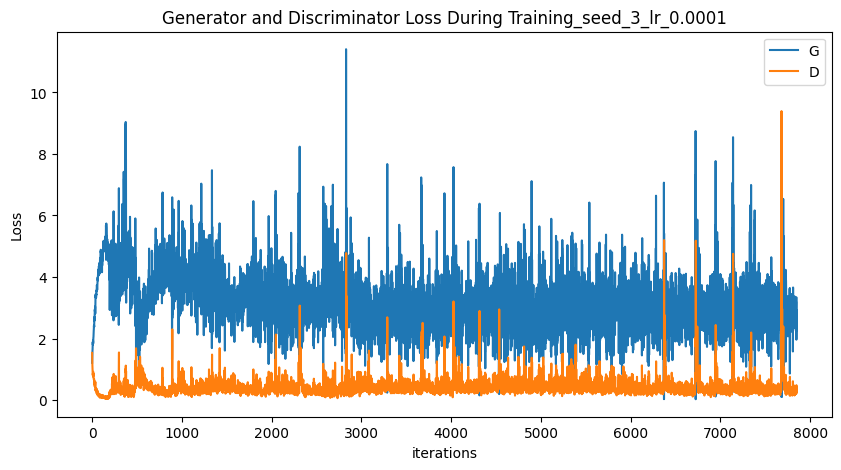

In [84]:
plt.figure(figsize=(10,5))
plt.title(f"Generator and Discriminator Loss During Training_seed_{seed}_lr_{lr}")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

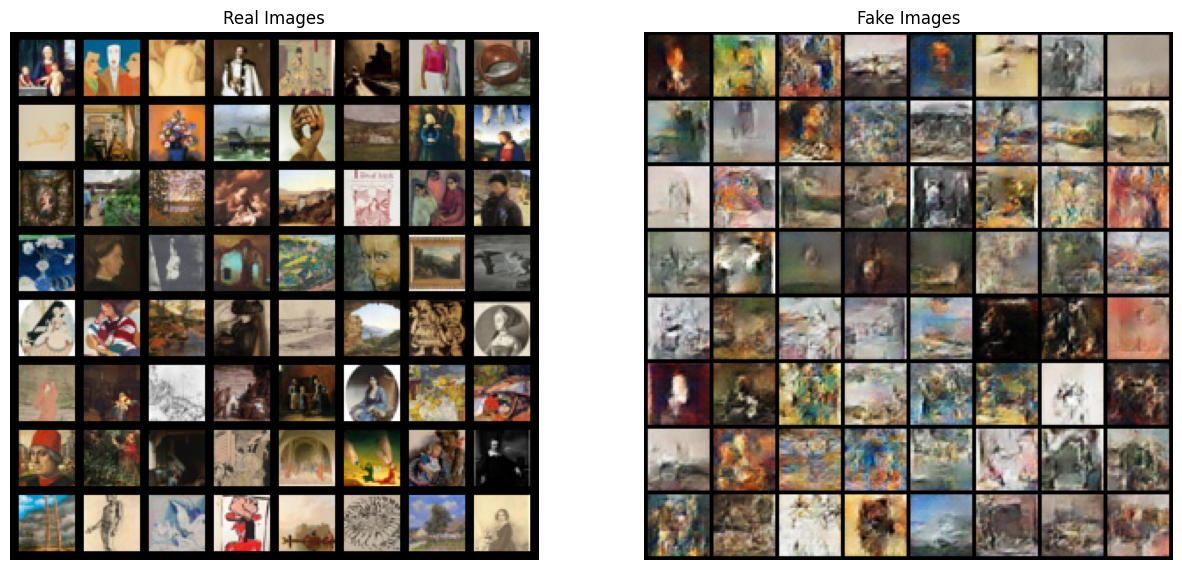

In [85]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(train_loader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVIDE)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

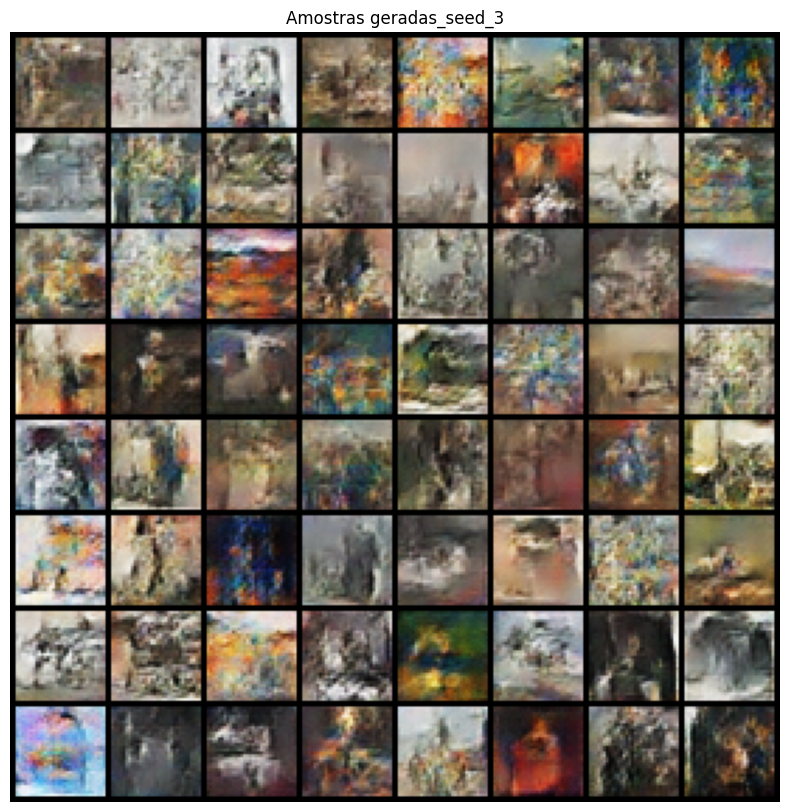

In [86]:
from pathlib import Path
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import torch

SAMPLES_DIR = PROJECT_ROOT / "results" / "samples" / f"seed_{seed}_lr_{lr}"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

netG.eval()
with torch.no_grad():
    noise = torch.randn(64, nz, 1, 1, device=DEVIDE)
    fake_images = netG(noise).cpu()
    fake_images = denorm(fake_images)


# guardar grelha
grid = make_grid(fake_images, nrow=8, padding=2)
save_image(grid, SAMPLES_DIR / "grid.png")

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Amostras geradas_seed_{seed}")
plt.show()

In [87]:
import torch

@torch.no_grad()
def generate_fake_images(generator, n_samples=5000, batch_size=64, latent_dim=100, device="cuda"):
    generator.eval()
    all_images = []

    total = 0
    while total < n_samples:
        current_batch = min(batch_size, n_samples - total)
        z = torch.randn(current_batch, latent_dim, 1, 1, device=device)
        fake = generator(z).cpu()
        fake = denorm(fake)   # passar de [-1,1] para [0,1]
        all_images.append(fake)
        total += current_batch

    return torch.cat(all_images, dim=0)

In [88]:
fake_images = generate_fake_images(netG, n_samples=5000, batch_size=64, latent_dim=nz, device=DEVIDE)
print(fake_images.shape)   # deve dar [5000, 3, 32, 32]

torch.Size([5000, 3, 32, 32])


In [89]:
@torch.no_grad()
def collect_real_images(dataloader, n_samples=5000):
    all_images = []
    total = 0

    for x, _, _ in dataloader:
        x = denorm(x.cpu())   # passar de [-1,1] para [0,1]
        all_images.append(x)
        total += x.size(0)

        if total >= n_samples:
            break

    return torch.cat(all_images, dim=0)[:n_samples]

In [90]:
real_images = collect_real_images(train_loader, n_samples=5000)
print(real_images.shape)

torch.Size([5000, 3, 32, 32])


In [91]:
!pip install torchmetrics[image]

In [92]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def to_uint8(x):
    x = (x * 255).clamp(0, 255).to(torch.uint8)
    return x

def compute_fid_kid(real_images, fake_images, device, batch_size=64):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(subset_size=100).to(device)

    # processar em mini-batches para não esgotar a VRAM
    for start in range(0, len(real_images), batch_size):
        batch = to_uint8(real_images[start:start + batch_size]).to(device)
        fid.update(batch, real=True)
        kid.update(batch, real=True)

    for start in range(0, len(fake_images), batch_size):
        batch = to_uint8(fake_images[start:start + batch_size]).to(device)
        fid.update(batch, real=False)
        kid.update(batch, real=False)

    fid_value = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    return {
        "fid": fid_value,
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item()
    }

In [93]:
metrics = compute_fid_kid(real_images, fake_images, DEVIDE)
print(metrics)

C:\Users\ritam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


{'fid': 100.00169372558594, 'kid_mean': 0.08330117166042328, 'kid_std': 0.008683860301971436}


In [94]:
import json

RESULTS_DIR = PROJECT_ROOT / "results"
CKPT_DIR = RESULTS_DIR / "checkpoints"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

json_path = RESULTS_DIR / f"metrics_gan_seed{seed}_lr_{lr}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump({
        "seed": seed,
        "metrics": metrics,
        "G_losses": G_losses,
        "D_losses": D_losses,
    }, f, indent=2)
print(f"Metricas guardadas em: {json_path}")

torch.save(netG.state_dict(), CKPT_DIR / f"netG_seed{seed}_lr_{lr}.pt")
torch.save(netD.state_dict(), CKPT_DIR / f"netD_seed{seed}_lr_{lr}.pt")


Metricas guardadas em: D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\results\metrics_gan_seed3_lr_0.0001.json


In [95]:
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path("results")
json_files = sorted(RESULTS_DIR.glob("metrics_gan_seed*.json"))

rows = []

for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    seed = data.get("seed", metrics.get("seed"))

    rows.append({
        "file": file.name,
        "seed": seed,
        "fid": metrics.get("fid"),
        "kid_mean": metrics.get("kid_mean"),
        "kid_std": metrics.get("kid_std"),
    })

df = pd.DataFrame(rows)
df = df.sort_values("fid").reset_index(drop=True)

df

,file,seed,fid,kid_mean,kid_std
0,metrics_gan_seed110.json,110,70.327774,0.050152,0.005931
1,metrics_gan_seed441.json,441,72.700264,0.053933,0.005773
2,metrics_gan_seed3.json,3,75.679634,0.054404,0.006171
3,metrics_gan_seed143.json,143,78.796555,0.057438,0.006348
4,metrics_gan_seed42_100.json,42,80.092163,0.059695,0.007380
5,metrics_gan_seed42.json,42,81.242271,0.063720,0.007728
6,metrics_gan_seed84.json,84,82.812897,0.059420,0.006180
7,metrics_gan_seed235.json,235,85.511551,0.063651,0.006806
8,metrics_gan_seed57.json,57,85.837883,0.064049,0.007605
9,metrics_gan_seed14_200.json,14,87.739113,0.067348,0.007325


In [96]:

best = df.iloc[0]

print("=== Melhor seed ===")
print(f"Ficheiro:  {best['file']}")
print(f"Seed:      {best['seed']}")
print(f"FID:       {best['fid']:.4f}")
print(f"KID mean:  {best['kid_mean']:.6f}")
print(f"KID std:   {best['kid_std']:.6f}")

=== Melhor seed ===
Ficheiro:  metrics_gan_seed110.json
Seed:      110
FID:       70.3278
KID mean:  0.050152
KID std:   0.005931
